# Project Type - EDA
# Industry - GNCIPL
# Contribution - Team
# Member Name 1 - Prakhar Khandelwal
# Member Name 2 - Prachi Saini 
# Task - Final Week Project

# Project Summary -

# Project Overview:
# This project focuses on analyzing socio-economic indicators across Indian states to understand how different factors such as poverty rate, unemployment rate, literacy level, GDP per capita, and population influence each other. The goal is to uncover hidden relationships, identify high-risk regions, and provide data-driven insights that can support policy recommendations and targeted interventions.
# The dataset contains state-wise information including population, literacy rate, unemployment rate, poverty rate, GDP per capita, and other demographic variables. By applying exploratory data analysis (EDA), statistical methods, and visualization techniques, the project highlights the disparities between states and reveals trends over time.
# The analysis includes key visualizations such as poverty distribution, unemployment trends, literacy-poverty correlations, and state comparisons. The project also incorporates regression and correlation analysis to study how literacy, unemployment, and GDP influence poverty. This helps in identifying potential socio-economic predictors of poverty and the regions that require urgent attention.
# Overall, the project provides a holistic view of the socio-economic landscape in India, enabling stakeholders to better understand root causes, compare states, and design meaningful development strategies based on evidence rather than assumptions.

# Problem Statement :
# Poverty and unemployment remain two of the most critical socio-economic challenges across Indian states. Despite several welfare schemes, many regions continue to exhibit high poverty rates and low employment opportunities, often influenced by factors such as literacy levels, GDP per capita, and population demographics. However, policymakers lack a consolidated, data-driven analysis that shows how these indicators interact with each other across different states.
# There is a need to systematically analyze the relationship between poverty, unemployment, literacy, and economic development indicators to identify high-risk regions, uncover hidden correlations, and understand the socio-economic conditions that drive poverty. Without such insights, the planning and allocation of welfare resources may remain suboptimal and inefficient.

# Objectives : 
# To integrate and clean multiple socio-economic datasets to create a unified, state-wise dataset for analysis.

# To analyze the correlation between poverty rate and unemployment rate across Indian states.

# To study the influence of literacy rate, GDP per capita, and population on poverty and unemployment levels.

# To perform regression analysis to identify key socio-economic predictors of poverty and unemployment.

# To visualize trends and patterns using charts such as scatter plots, line charts, bar charts, bubble charts, and heatmaps.

# To derive actionable insights for social welfare policy-making, particularly for poverty reduction and employment generation.

# To design an interactive dashboard (Power BI / Tableau) showcasing KPIs and visual insights for planners and stakeholders.

# Let's Begin The Project

# Import Libraries 

In [89]:
# For data processing & data wrangling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


# Dataset Loading

In [98]:
# Load Dataset
df1 = pd.read_csv(r"C:\Users\Prakhar Khandelwal\Downloads\Base_Dataset.csv")
df2 = pd.read_csv(r"C:\Users\Prakhar Khandelwal\Downloads\Literacy_Dataset.csv")
df3 = pd.read_csv(r"C:\Users\Prakhar Khandelwal\Downloads\Unemployment_Dataset.csv")

# Merginng Dataset

In [100]:
# Creating a Common Column for Merging
df1['State_ID'] = range(1, 701)
df2['State_ID'] = range(1, 701)
df3['State_ID'] = range(1, 701)

merge1 = pd.merge(df1, df2, on="State_ID", how="inner")
df = pd.merge(merge1, df3, on="State_ID", how="inner")

In [101]:
# Dropping the extra columns
df = df.drop(["State_ID", "State_y", "Year_y", "State", "Year", "State"], axis=1)
df.head()

,State_x,Year_x,Population,GDP per Capita (INR),Poverty_rate,Literacy_rate,Male Literacy Rate (%),Female Literacy Rate (%),School Enrollment Rate (%),Dropout_Rate,Labor Force Participation Rate (%),Unemployment_rate,Youth Unemployment Rate (%),Female Unemployment Rate (%),Employment in Agriculture (%),Employment in Services (%)
0,Mizoram,2022,2163687,96490,20.751036,71.036471,0.8060,0.8264,0.7863,4.220029,0.3487,6.498160,0.0567,0.1968,0.3670,0.2226
1,Jharkhand,2022,1381604,35454,21.293969,76.732086,0.8046,0.9341,0.8336,8.418412,0.4781,8.802857,0.2271,0.1790,0.6677,0.2831
2,Rajasthan,2019,302515,140494,20.702218,72.688294,0.6007,0.6021,0.5741,7.982827,0.3449,7.927976,0.0863,0.1974,0.6766,0.1737
3,Delhi,2021,345625,119180,19.041580,71.267499,0.7778,0.8940,0.5598,6.847785,0.4200,7.394634,0.1913,0.1469,0.5385,0.2067
4,Chandigarh,2018,462610,83871,19.479552,89.799205,0.9655,0.9462,0.6396,9.065023,0.4053,5.624075,0.1195,0.1277,0.1877,0.3495


# Data Manipulation & Wrangling

In [102]:
# Rename the Columns
df = df.rename(columns={
    "State_x": "State",
    "Year_x": "Year",
    "Poverty Rate (%)": "Poverty_rate",
    "Literacy Rate (%)": "Literacy_rate",
    "Male Literacy Rate (%)": "Male_Literacy_Rate",
    "Female Literacy Rate (%)": "Female_Literacy_Rate",
    "School Enrollment Rate (%)": "School_Enrollment_Rate",
    "Dropout Rate (%)": "Dropout_Rate",
    "Labor Force Participation Rate (%)": "LFP_Rate",
    "Unemployment Rate (%)": "Unemployment_rate",
    "Youth Unemployment Rate (%)": "Youth_Unemployment_Rate",
    "Female Unemployment Rate (%)": "Female_Unemployment_Rate",
    "Employment in Agriculture (%)": "Employment_in_Agriculture",
    "Employment in Services (%)": "Employment_in_Services",
    "Population": "Population(M)",
})
# Convert population to millions
df["Population(M)"] = df["Population(M)"] / 1_000_000
df["Population(M)"] = df["Population(M)"].round(2)

# Final Dataset

In [103]:
df.head()

,State,Year,Population(M),GDP per Capita (INR),Poverty_rate,Literacy_rate,Male_Literacy_Rate,Female_Literacy_Rate,School_Enrollment_Rate,Dropout_Rate,LFP_Rate,Unemployment_rate,Youth_Unemployment_Rate,Female_Unemployment_Rate,Employment_in_Agriculture,Employment_in_Services
0,Mizoram,2022,2.16,96490,20.751036,71.036471,0.8060,0.8264,0.7863,4.220029,0.3487,6.498160,0.0567,0.1968,0.3670,0.2226
1,Jharkhand,2022,1.38,35454,21.293969,76.732086,0.8046,0.9341,0.8336,8.418412,0.4781,8.802857,0.2271,0.1790,0.6677,0.2831
2,Rajasthan,2019,0.30,140494,20.702218,72.688294,0.6007,0.6021,0.5741,7.982827,0.3449,7.927976,0.0863,0.1974,0.6766,0.1737
3,Delhi,2021,0.35,119180,19.041580,71.267499,0.7778,0.8940,0.5598,6.847785,0.4200,7.394634,0.1913,0.1469,0.5385,0.2067
4,Chandigarh,2018,0.46,83871,19.479552,89.799205,0.9655,0.9462,0.6396,9.065023,0.4053,5.624075,0.1195,0.1277,0.1877,0.3495


# Dataset Information

In [11]:
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   State                      700 non-null    object 
 1   Year                       700 non-null    int64  
 2   Population(M)              700 non-null    float64
 3   GDP per Capita (INR)       700 non-null    int64  
 4   Literacy_rate              700 non-null    float64
 5   Male_Literacy_Rate         700 non-null    float64
 6   Female_Literacy_Rate       700 non-null    float64
 7   School_Enrollment_Rate     700 non-null    float64
 8   Dropout_Rate               700 non-null    float64
 9   LFP_Rate                   700 non-null    float64
 10  Unemployment_rate          700 non-null    float64
 11  Youth_Unemployment_Rate    700 non-null    float64
 12  Female_Unemployment_Rate   700 non-null    float64
 13  Employment_in_Agriculture  700 non-null    float64

# Duplicate Values

In [12]:
# Dataset Duplicate Value Count
dup = df.duplicated().sum()
print(f'Number of duplicated rows are {dup}')

Number of duplicated rows are 0


# Missing Values/Null Values

In [13]:
# Missing Values/Null Values Count
df.isnull().sum()

State                        0
Year                         0
Population(M)                0
GDP per Capita (INR)         0
Literacy_rate                0
Male_Literacy_Rate           0
Female_Literacy_Rate         0
School_Enrollment_Rate       0
Dropout_Rate                 0
LFP_Rate                     0
Unemployment_rate            0
Youth_Unemployment_Rate      0
Female_Unemployment_Rate     0
Employment_in_Agriculture    0
Employment_in_Services       0
dtype: int64

# Understanding the Dataset

In [14]:
# Dataset Columns
df.columns

Index(['State', 'Year', 'Population(M)', 'GDP per Capita (INR)',
       'Literacy_rate', 'Male_Literacy_Rate', 'Female_Literacy_Rate',
       'School_Enrollment_Rate', 'Dropout_Rate', 'LFP_Rate',
       'Unemployment_rate', 'Youth_Unemployment_Rate',
       'Female_Unemployment_Rate', 'Employment_in_Agriculture',
       'Employment_in_Services'],
      dtype='object')

In [32]:
# Dataset Describe (all columns included)
df.describe(include= 'all')

,State,Year,Population(M),GDP per Capita (INR),Poverty_rate,Literacy_rate,Male_Literacy_Rate,Female_Literacy_Rate,School_Enrollment_Rate,Dropout_Rate,LFP_Rate,Unemployment_rate,Youth_Unemployment_Rate,Female_Unemployment_Rate,Employment_in_Agriculture,Employment_in_Services
count,700,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
unique,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Himachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2020.550000,1.501900,137609.002857,19.918857,76.497686,79.615343,74.031943,75.116557,10.42290,49.539129,8.394000,14.894129,11.360357,39.936257,34.580443
std,NaN,1.711382,0.835174,64557.922867,8.510896,12.362245,11.360474,14.020756,14.422445,5.34447,11.476332,3.642643,5.776245,4.920275,17.299835,14.821301
min,NaN,2018.000000,0.050000,30015.000000,5.000000,55.210000,60.030000,50.070000,50.090000,1.06000,30.040000,2.020000,5.010000,3.050000,10.320000,10.050000
25%,NaN,2019.000000,0.775000,81442.250000,13.000000,66.177500,69.902500,61.440000,62.245000,5.90500,38.867500,5.287500,9.875000,7.147500,25.247500,21.205000
50%,NaN,2021.000000,1.525000,135542.000000,19.600000,76.640000,79.835000,73.295000,75.805000,10.44500,49.500000,8.480000,15.180000,10.995000,40.540000,35.445000
75%,NaN,2022.000000,2.170000,193943.500000,27.400000,87.110000,89.660000,86.495000,87.760000,14.91250,59.635000,11.397500,19.732500,15.715000,54.772500,47.662500


# Data Vizualization

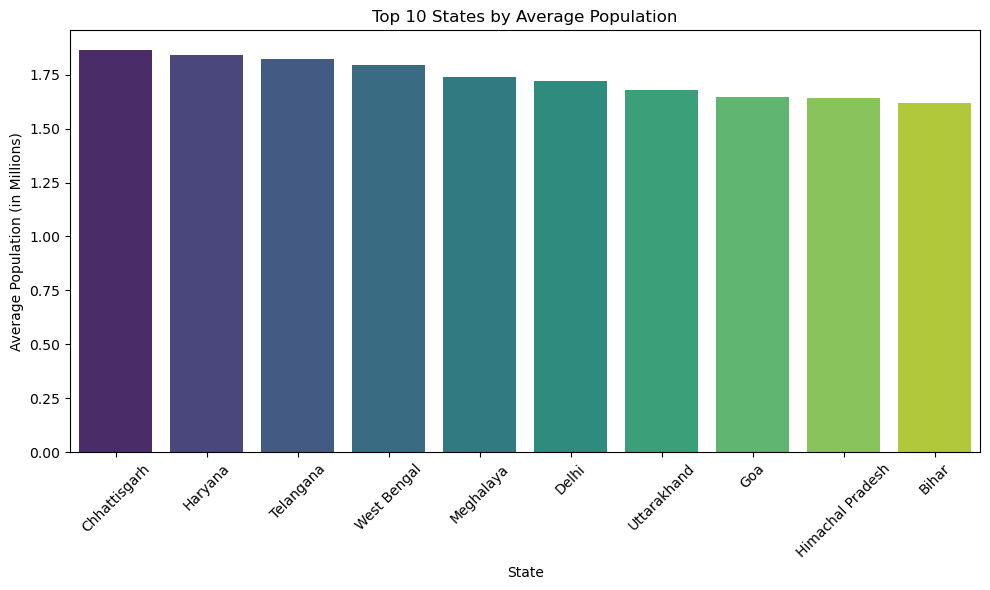

In [110]:
# Calculate average population by state and select top 10
avg_population_top10 = (
    df.groupby("State")["Population(M)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_population_top10.index,
    y=avg_population_top10.values,
    palette="viridis"
)

plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Average Population (in Millions)")
plt.title("Top 10 States by Average Population")

plt.tight_layout()
plt.show()

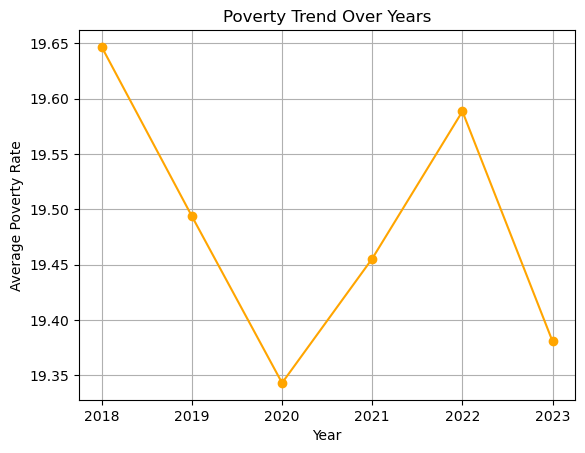

In [111]:
# Line Chart : Poverty Trend Over Time
year_poverty = df.groupby("Year")["Poverty_rate"].mean()

plt.plot(year_poverty.index, year_poverty.values, marker="o", color="orange")
plt.xlabel("Year")
plt.ylabel("Average Poverty Rate")
plt.title("Poverty Trend Over Years")
plt.grid(True)
plt.show()

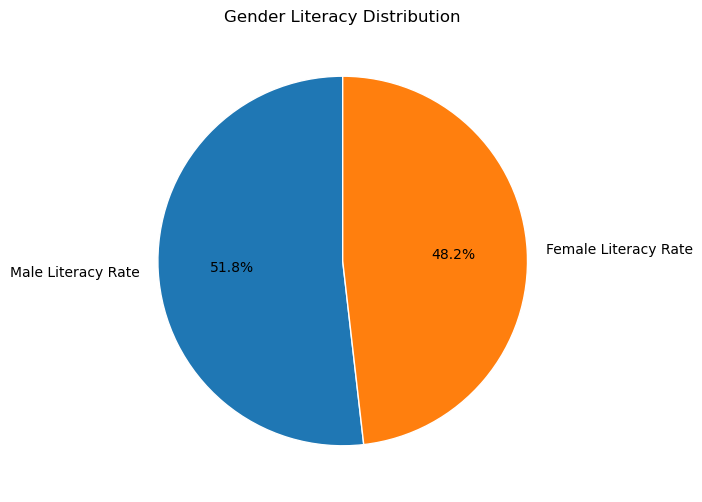

In [112]:
# Calculate average male and female literacy rates
male_avg = df['Male_Literacy_Rate'].mean()
female_avg = df['Female_Literacy_Rate'].mean()

# Labels and values
labels = ['Male Literacy Rate', 'Female Literacy Rate']
sizes = [male_avg, female_avg]

# Plot pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Gender Literacy Distribution")
plt.show()

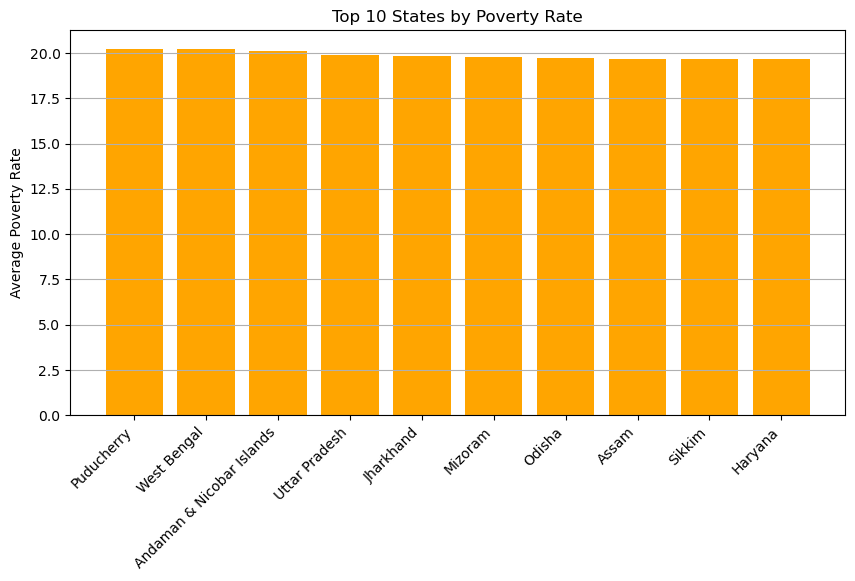

In [113]:
# Bar Chart : Top 10 States by Poverty Rate
state_poverty = df.groupby("State")["Poverty_rate"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(state_poverty.index, state_poverty.values, color="orange")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Poverty Rate")
plt.title("Top 10 States by Poverty Rate")
plt.grid(axis="y")
plt.show()

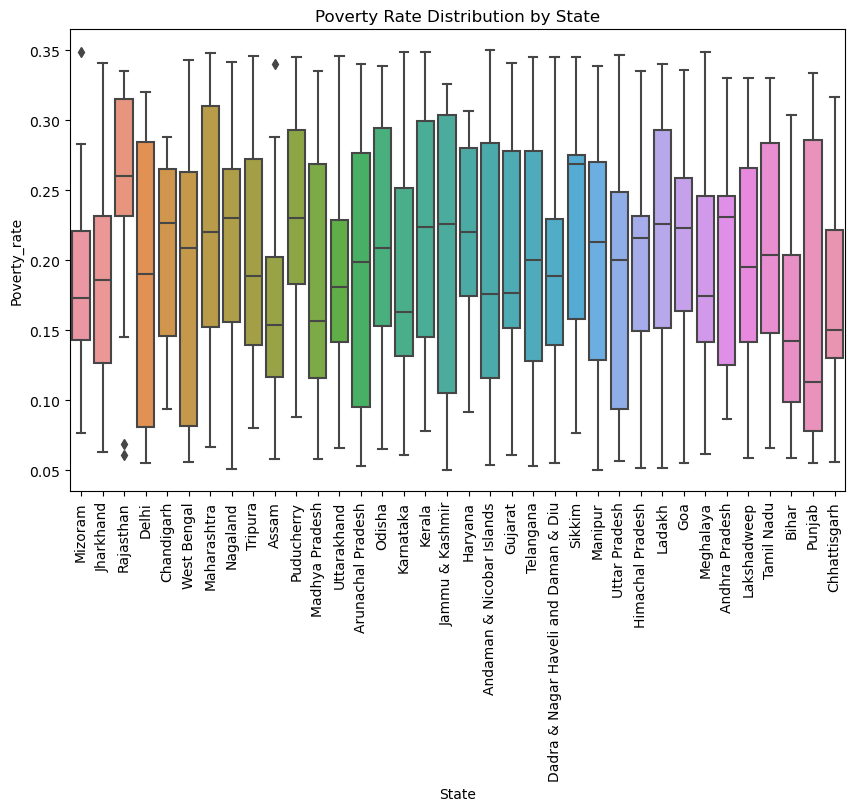

In [49]:
# Box Plot : Poverty Rate Distribution by State
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="State", y="Poverty_rate")
plt.xticks(rotation=90)
plt.title("Poverty Rate Distribution by State")
plt.show()

Text(0, 0.5, 'Poverty Rate (%)')

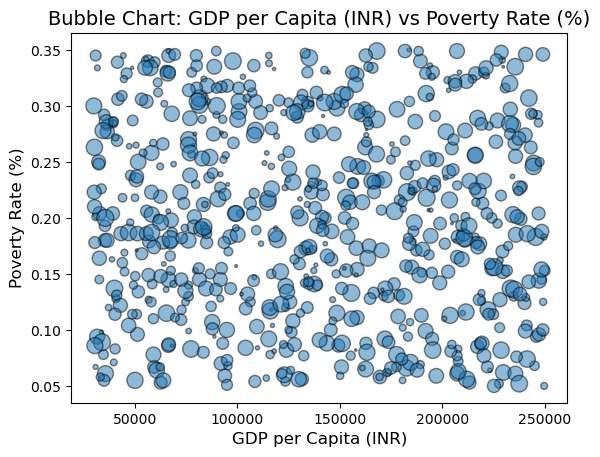

In [50]:
# Bubble Chart : GDP vs Poverty rate
plt.scatter(
    df["GDP per Capita (INR)"],
    df["Poverty_rate"],
    s=df["Population(M)"] * 50,   # bubble size scaled
    alpha=0.5,
    edgecolor="black"
)

plt.title("Bubble Chart: GDP per Capita (INR) vs Poverty Rate (%)", fontsize=14)
plt.xlabel("GDP per Capita (INR)", fontsize=12)
plt.ylabel("Poverty Rate (%)", fontsize=12)

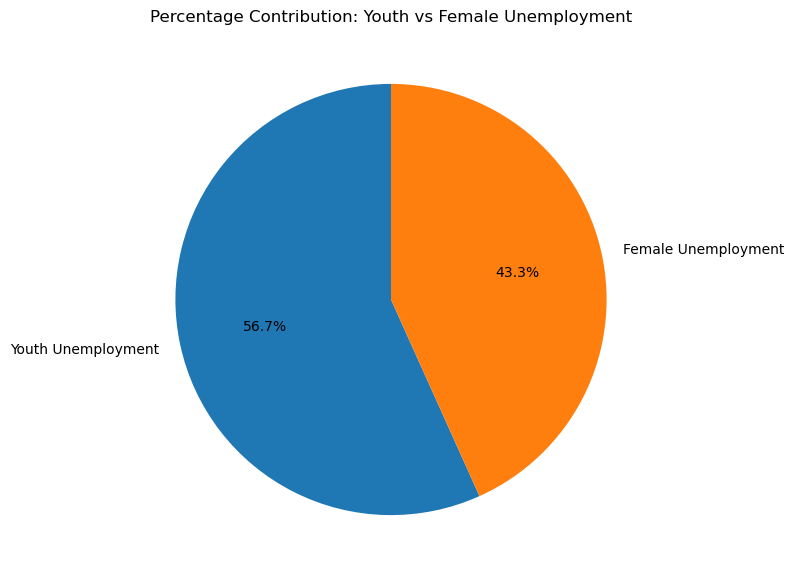

In [51]:
# Calculate the average unemployment rates
avg_youth = df["Youth_Unemployment_Rate"].mean()
avg_female = df["Female_Unemployment_Rate"].mean()

data = [avg_youth, avg_female]
labels = ["Youth Unemployment", "Female Unemployment"]

plt.figure(figsize=(7,7))
plt.pie(data, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Percentage Contribution: Youth vs Female Unemployment")
plt.show()

C:\Users\Prakhar Khandelwal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Prakhar Khandelwal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Prakhar Khandelwal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Prakhar Khandelwal\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

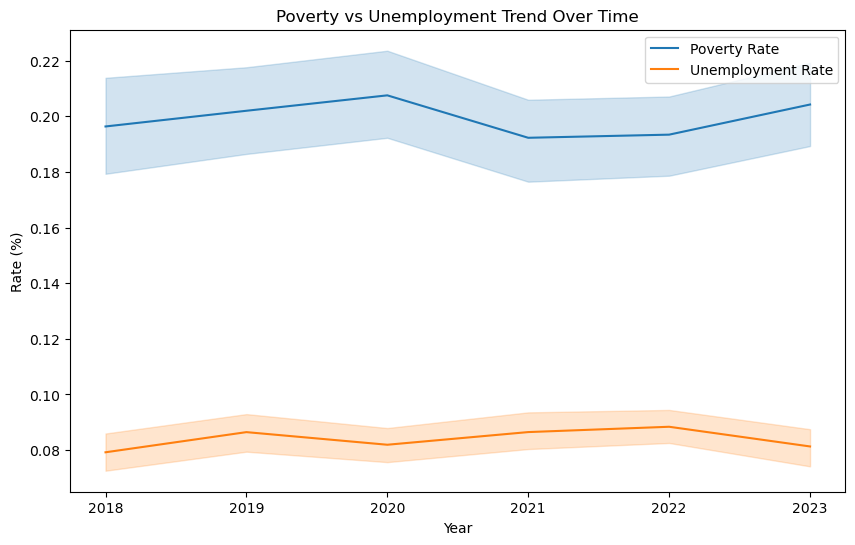

In [52]:
# Line Chart : Poverty vs Unemployment Trend Over Time
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Year", y="Poverty_rate", label="Poverty Rate")
sns.lineplot(data=df, x="Year", y="Unemployment_rate", label="Unemployment Rate")
plt.title("Poverty vs Unemployment Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.legend()
plt.show()

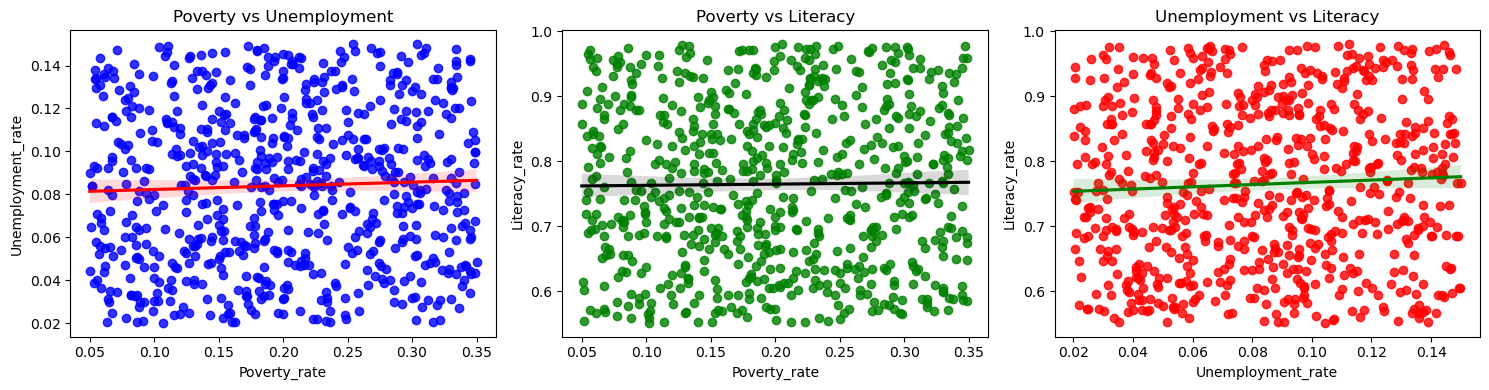

In [53]:
# Scatter Chart layout for : Poverty vs Unemployment, Poverty vs Literacy, Unemployment vs Literacy
plt.figure(figsize=(15,4))

# Poverty vs Unemployment
plt.subplot(1,3,1)
sns.regplot(
    data=df, x="Poverty_rate", y="Unemployment_rate",
    scatter_kws={"color": "blue"},      # Dot color
    line_kws={"color": "red"}         # Trendline color
)
plt.title("Poverty vs Unemployment")

# Poverty vs Literacy
plt.subplot(1,3,2)
sns.regplot(
    data=df, x="Poverty_rate", y="Literacy_rate",
    scatter_kws={"color": "green"},
    line_kws={"color": "black"}
)
plt.title("Poverty vs Literacy")

# Unemployment vs Literacy
plt.subplot(1,3,3)
sns.regplot(
    data=df, x="Unemployment_rate", y="Literacy_rate",
    scatter_kws={"color": "red"},
    line_kws={"color": "green"}
)
plt.title("Unemployment vs Literacy")

plt.tight_layout()
plt.show()

# Correlation Analysis

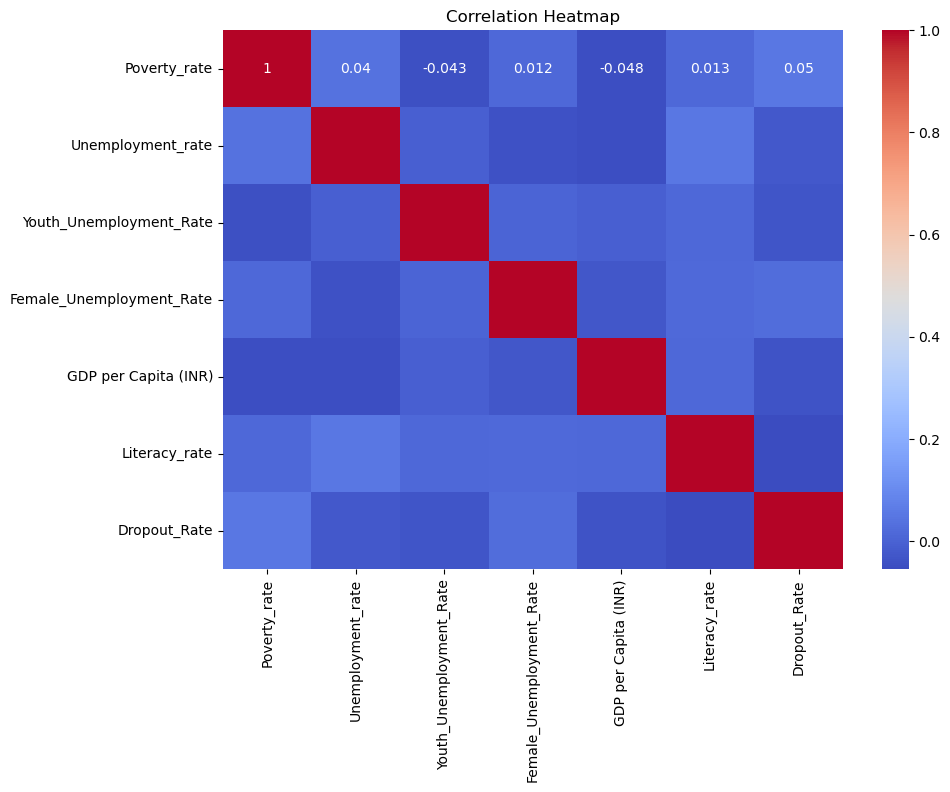

In [61]:
# Correlation Analysis : 
corr_cols = ["Poverty_rate", "Unemployment_rate",
             "Youth_Unemployment_Rate", "Female_Unemployment_Rate",
             "GDP per Capita (INR)","Literacy_rate", "Dropout_Rate"]

plt.figure(figsize=(10,7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Regression Analysis

In [81]:
df.head()

,State,Year,Population(M),GDP per Capita (INR),Poverty_rate,Literacy_rate,Male_Literacy_Rate,Female_Literacy_Rate,School_Enrollment_Rate,Dropout_Rate,LFP_Rate,Unemployment_rate,Youth_Unemployment_Rate,Female_Unemployment_Rate,Employment_in_Agriculture,Employment_in_Services
0,Mizoram,2022,2.16,96490,0.183,80.651789,0.8060,0.8264,0.7863,4.169293,0.3487,5.872701,0.0567,0.1968,0.3670,0.2226
1,Jharkhand,2022,1.38,35454,0.193,71.036471,0.8046,0.9341,0.8336,4.173335,0.4781,8.753572,0.2271,0.1790,0.6677,0.2831
2,Rajasthan,2019,0.30,140494,0.307,76.732086,0.6007,0.6021,0.5741,3.256700,0.3449,7.659970,0.0863,0.1974,0.6766,0.1737
3,Delhi,2021,0.35,119180,0.273,72.688294,0.7778,0.8940,0.5598,8.154814,0.4200,6.993292,0.1913,0.1469,0.5385,0.2067
4,Chandigarh,2018,0.46,83871,0.193,71.267499,0.9655,0.9462,0.6396,7.646632,0.4053,4.780093,0.1195,0.1277,0.1877,0.3495


In [104]:
# Selecting the independent variables (features) for the model
X = df[["Unemployment_rate", "Literacy_rate","GDP per Capita (INR)",
    "Dropout_Rate"]]

In [105]:
# Selecting the target variable (what we want to predict)
y = df["Poverty_rate"]

In [106]:
# Splitting the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
# Creating a Linear Regression model
model = LinearRegression()

# Training the model using the training data
model.fit(X_train, y_train)

LinearRegression()

In [109]:
# Predicting the poverty rate for the test dataset
y_pred = model.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Displaying the coefficients of each feature
print("Coefficients:", model.coef_)

# Displaying the intercept value
print("Intercept:", model.intercept_)

R2 Score: 0.13489758385108952
Mean Squared Error (MSE): 1.5596043083627515
Coefficients: [ 2.17017748e-01  4.01842155e-03 -5.39484898e-06  5.21159300e-02]
Intercept: 18.000865392581066


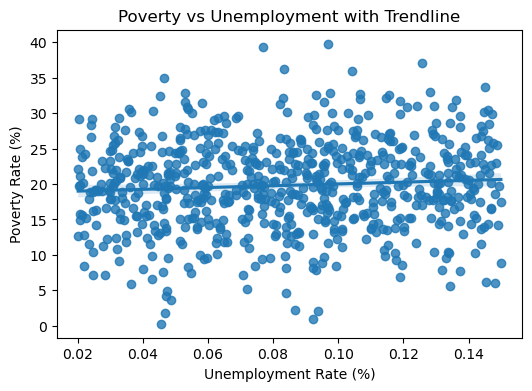

In [37]:
# Scatter Plot with Trendline

plt.figure(figsize=(6,4))
sns.regplot(x=df["Unemployment_rate"], y=df["Poverty_rate"])
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Poverty Rate (%)")
plt.title("Poverty vs Unemployment with Trendline")
plt.show()